In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load and normalize Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 🧠 Build Model
def build_model():
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10)
    ])

model = build_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam()

In [4]:
# 🔎 Metrics
train_loss_metric = keras.metrics.Mean(name="train_loss")
train_accuracy_metric = keras.metrics.SparseCategoricalAccuracy(name="train_accuracy")
val_loss_metric = keras.metrics.Mean(name="val_loss")
val_accuracy_metric = keras.metrics.SparseCategoricalAccuracy(name="val_accuracy")

In [5]:
# 📦 Prepare Datasets
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

In [6]:
# 🔁 Custom Training Loop
epochs = 5
train_loss_log, val_loss_log = [], []
train_acc_log, val_acc_log = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    train_loss_metric.reset_state()
    train_accuracy_metric.reset_state()
    val_loss_metric.reset_state()
    val_accuracy_metric.reset_state()

    # Training step
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss = loss_fn(y_batch, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_loss_metric.update_state(loss)
        train_accuracy_metric.update_state(y_batch, logits)

    # Validation step
    for x_batch_val, y_batch_val in val_dataset:
        val_logits = model(x_batch_val, training=False)
        val_loss = loss_fn(y_batch_val, val_logits)
        val_loss_metric.update_state(val_loss)
        val_accuracy_metric.update_state(y_batch_val, val_logits)

    # Logging
    train_loss_log.append(train_loss_metric.result().numpy())
    val_loss_log.append(val_loss_metric.result().numpy())
    train_acc_log.append(train_accuracy_metric.result().numpy())
    val_acc_log.append(val_accuracy_metric.result().numpy())

    print(f"Train Loss: {train_loss_log[-1]:.4f} | Train Acc: {train_acc_log[-1]:.4f} | Val Loss: {val_loss_log[-1]:.4f} | Val Acc: {val_acc_log[-1]:.4f}")


Epoch 1/5
Train Loss: 0.4781 | Train Acc: 0.8285 | Val Loss: 0.3550 | Val Acc: 0.8736

Epoch 2/5
Train Loss: 0.3154 | Train Acc: 0.8856 | Val Loss: 0.3314 | Val Acc: 0.8787

Epoch 3/5
Train Loss: 0.2719 | Train Acc: 0.9011 | Val Loss: 0.2820 | Val Acc: 0.8978

Epoch 4/5
Train Loss: 0.2375 | Train Acc: 0.9129 | Val Loss: 0.2696 | Val Acc: 0.9015

Epoch 5/5
Train Loss: 0.2152 | Train Acc: 0.9205 | Val Loss: 0.2631 | Val Acc: 0.9047


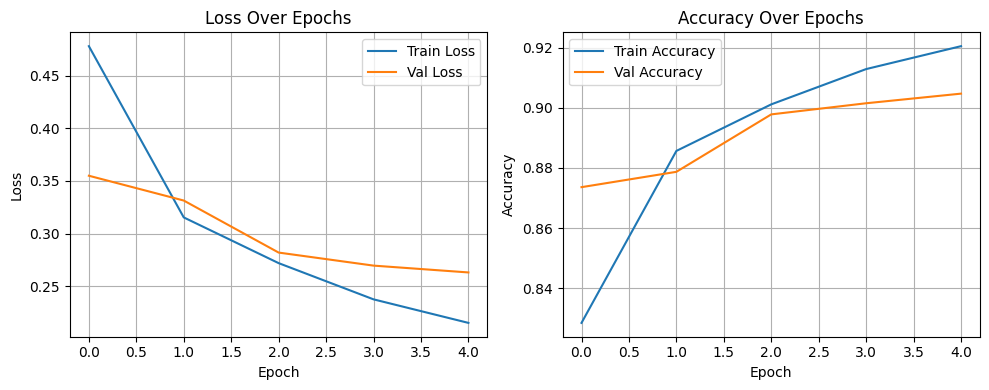

In [7]:
# 📊 Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_log, label="Train Loss")
plt.plot(val_loss_log, label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_log, label="Train Accuracy")
plt.plot(val_acc_log, label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()